In [2]:
!pip install ml4eft

In [3]:
!pip install wget


In [4]:
!lhapdf install NNPDF31_lo_as_0118


PDF already installed: NNPDF31_lo_as_0118 (use --upgrade to force install)


In [5]:
import wget
import tarfile
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rc

import numpy as np
np.float = float  # patch for deprecated usage

import ml4eft.core.classifier as classifier
import ml4eft.analyse.analyse as analyse
import ml4eft.plotting.features as features

rc('text', usetex=False)
rc('font', **{'family': 'DejaVu Sans', 'size': 22})

LHAPDF 6.5.4 loading /depot/cms/purdue-af/lhapdf/share/LHAPDF/NNPDF31_lo_as_0118/NNPDF31_lo_as_0118_0000.dat
NNPDF31_lo_as_0118 PDF set, member #0, version 1; LHAPDF ID = 315000


In [6]:
def file_downloader(url, download_dir='./downloads'):

    if not os.path.exists(download_dir):
        os.mkdir(download_dir)

    file = wget.download(url, out=download_dir)
    return file

def untar(path_to_tar, destination='./downloads'):

    with tarfile.open(path_to_tar) as f:
        f.extractall(destination)

download_dir = './downloads'

In [7]:
training_data_url = 'https://dl.dropboxusercontent.com/s/z16fz2ggbn244pl/training_data.tar.gz?dl=0'
training_data = file_downloader(training_data_url);
data_train_loc = training_data.split('.tar')[0]

untar(training_data);

In [8]:
# load eft events
coeff = ["ctGRe", "ctj8"]
events_eft = []
for c in coeff:
    path_to_events = os.path.join(data_train_loc, 'tt_{}_{}/events_0.pkl.gz'.format(c, c))
    events, xsec = analyse.Analyse.load_events(path_to_events)
    events_eft.append(events)

# load sm events
events_sm, xsec_sm = analyse.Analyse.load_events(os.path.join(download_dir, 'training_data/tt_sm/events_0.pkl.gz'))
events_sm

,sqrts_hat,pt_l1,pt_l2,pt_l_leading,pt_l_trailing,eta_l1,eta_l2,eta_l_leading,eta_l_trailing,pt_ll,m_ll,DeltaPhi_ll,DeltaEta_ll,pt_b_leading,pt_b_trailing,eta_b_leading,eta_b_trailing,pt_bb,m_bb
1,1702.356400,20.532279,308.295118,308.295118,20.532279,-2.065020,-1.378378,-1.378378,-2.065020,288.661066,167.050330,2.854611,0.686642,719.441642,61.252983,-0.595103,-0.297553,674.939606,397.329956
2,1597.155835,321.296675,93.732180,321.296675,93.732180,2.395675,-0.667281,2.395675,-0.667281,243.808973,835.572285,2.631851,1.728394,228.819181,36.771409,0.064635,2.310805,202.872663,304.906431
3,1860.212511,42.634066,40.346863,42.634066,40.346863,-1.342324,1.666454,-1.342324,1.666454,61.587173,185.989824,1.469631,-0.324129,236.676532,178.887249,-2.127759,1.122896,61.457333,1085.595391
4,1671.151358,44.365954,68.175665,68.175665,44.365954,-1.760597,1.686737,1.686737,-1.760597,51.301018,314.810493,2.289832,0.073860,219.833441,136.899478,1.415762,-1.433425,91.365016,761.785714
5,1467.940000,148.790522,386.021918,386.021918,148.790522,0.689735,-0.993332,-0.993332,0.689735,238.946708,658.674901,3.022271,-0.303597,92.528392,78.369846,-0.388545,0.147944,39.214238,172.644465
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99996,1569.717169,105.491453,215.354621,215.354621,105.491453,1.638092,-0.392135,-0.392135,1.638092,114.986825,469.344045,2.915923,1.245957,160.908767,50.601298,0.043227,0.524358,117.914163,180.981245
99997,1644.498574,38.643304,204.035995,204.035995,38.643304,0.507470,-1.391929,-1.391929,0.507470,185.001844,250.524232,2.170360,-0.884459,260.745097,143.029550,1.227220,-1.177890,179.188087,687.684884
99998,2045.033022,152.320608,177.281070,177.281070,152.320608,-0.246921,0.587674,0.587674,-0.246921,119.945338,337.901110,2.411552,-0.340753,360.362755,145.677331,-0.768837,0.257552,289.274374,482.420600
99999,1763.820943,105.010343,424.436796,424.436796,105.010343,1.104649,-0.186152,-0.186152,1.104649,436.408355,418.359318,1.578891,0.918498,380.500925,302.336989,0.654496,-0.008499,682.650395,229.570577


In [9]:
xsec_sm

0.03230263

In [10]:
events_eft

[          sqrts_hat       pt_l1       pt_l2  pt_l_leading  pt_l_trailing  \
 1       1740.260341  379.541131   40.825193    379.541131      40.825193   
 2       2255.153130  110.397912  182.430314    182.430314     110.397912   
 3       1488.022909   32.193554  199.171880    199.171880      32.193554   
 4       1487.293542   34.746519  363.884370    363.884370      34.746519   
 5       1510.765652   49.336622   65.071294     65.071294      49.336622   
 ...             ...         ...         ...           ...            ...   
 99996   1470.502350  193.933302   68.430179    193.933302      68.430179   
 99997   1550.336161  211.562032  209.341613    211.562032     209.341613   
 99998   2292.698434   22.126084  222.764183    222.764183      22.126084   
 99999   2099.552628   32.117129  170.819436    170.819436      32.117129   
 100000  2288.545047   93.838349  238.400567    238.400567      93.838349   
 
           eta_l1    eta_l2  eta_l_leading  eta_l_trailing       pt_ll  \


In [11]:
# load sm events
events_ctGRe, xsec_sm = analyse.Analyse.load_events(os.path.join(download_dir, 'training_data/tt_ctGRe/events_0.pkl.gz'))
events_ctGRe

,sqrts_hat,pt_l1,pt_l2,pt_l_leading,pt_l_trailing,eta_l1,eta_l2,eta_l_leading,eta_l_trailing,pt_ll,m_ll,DeltaPhi_ll,DeltaEta_ll,pt_b_leading,pt_b_trailing,eta_b_leading,eta_b_trailing,pt_bb,m_bb
1,1724.004816,118.420141,100.892375,118.420141,100.892375,1.164600,0.541281,1.164600,0.541281,17.981387,229.279083,3.104873,0.623319,431.834977,404.210239,1.158101,0.280498,28.654655,917.301269
2,1822.169788,158.502614,115.222031,158.502614,115.222031,-1.208619,-0.038120,-1.208619,-0.038120,88.437639,308.408757,2.562861,1.170499,261.876304,211.790258,-1.431800,-0.474995,127.949582,512.598824
3,1840.322378,75.475797,70.312819,75.475797,70.312819,0.866933,-0.430370,0.866933,-0.430370,6.947708,177.377083,3.077763,0.436563,130.442185,90.114088,0.339375,0.286141,49.674078,214.967150
4,2137.437579,114.181131,100.207824,114.181131,100.207824,0.719412,-2.374924,0.719412,-2.374924,39.810396,523.988012,2.791307,-1.655512,246.838419,66.916591,-1.994766,2.050593,181.344020,988.174427
5,2214.114645,305.205219,227.085929,305.205219,227.085929,-0.752116,1.181114,-0.752116,1.181114,85.677383,791.483862,3.007843,-0.428998,450.871718,91.721349,0.939272,-0.513217,366.747781,513.428896
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99996,1507.486241,409.769279,166.021302,409.769279,166.021302,1.137695,0.109511,1.137695,0.109511,265.307924,582.777081,2.737186,1.028184,336.954199,205.915284,0.101992,0.645775,131.475423,546.304794
99997,1968.715424,205.032005,51.493837,205.032005,51.493837,-0.817687,1.747166,-0.817687,1.747166,163.018261,395.178846,2.601925,-0.929480,193.281257,133.433357,2.311097,-1.409621,64.501134,1056.695803
99998,1518.162138,22.430118,116.083295,116.083295,22.430118,1.281344,-1.965880,-1.965880,1.281344,102.264726,265.682833,2.313138,-0.684537,167.880841,139.599429,0.490827,-0.813276,32.152363,373.291560
99999,1491.486601,74.776540,472.567065,472.567065,74.776540,0.961953,-0.401585,-0.401585,0.961953,405.377770,460.201206,2.723279,0.560368,371.833669,82.934391,0.404033,-0.779419,314.950499,395.085408


In [12]:
feature_dict = {'pt_l1': r'$p_T^{\ell}\;[\mathrm{GeV}]$',
            'pt_l2': r'$p_T^{\bar{\ell}}\;[\mathrm{GeV}]$',
            'pt_l_leading': r'$p_T^{\ell}\;(\mathrm{leading})\;[\mathrm{GeV}]$',
            'pt_l_trailing': r'$p_T^{\ell}\;(\mathrm{trailing})\;[\mathrm{GeV}]$',
            'eta_l1': r'$\eta_\ell$',
            'eta_l2': r'$\eta_{\bar{\ell}}$',
            'eta_l_leading': r'$\eta_\ell\;(\mathrm{leading})$',
            'eta_l_trailing': r'$\eta_\ell\;(\mathrm{trailing})$',
            'pt_ll': r'$p_T^{\ell\bar{\ell}}\;[\mathrm{GeV}]$',
            'm_ll': r'$m_{\ell\bar{\ell}}\;[\mathrm{GeV}]$',
            'DeltaPhi_ll': r'$\Delta\phi(\ell, \bar{\ell})$',
            'DeltaEta_ll': r'$\Delta\eta(\ell, \bar{\ell})$',
            'pt_b_leading': r'$p_T^{b}\;(\mathrm{leading})\;[\mathrm{GeV}]$',
            'pt_b_trailing': r'$p_T^{b}\;(\mathrm{trailing})\;[\mathrm{GeV}]$',
            'eta_b_leading': r'$\eta_{b}\;(\mathrm{leading})$',
            'eta_b_trailing': r'$\eta_{b}\;(\mathrm{trailing})$',
            'pt_bb': r'$p_T^{b\bar{b}}\;[\mathrm{GeV}]$',
            'm_bb': r'$m_{b\bar{b}}\;[\mathrm{GeV}]$'
         }

legend_labels = [r'$c_{tG}=10$', r'$c_{qt}^{(8)}=10$', r'$\mathrm{SM}$']


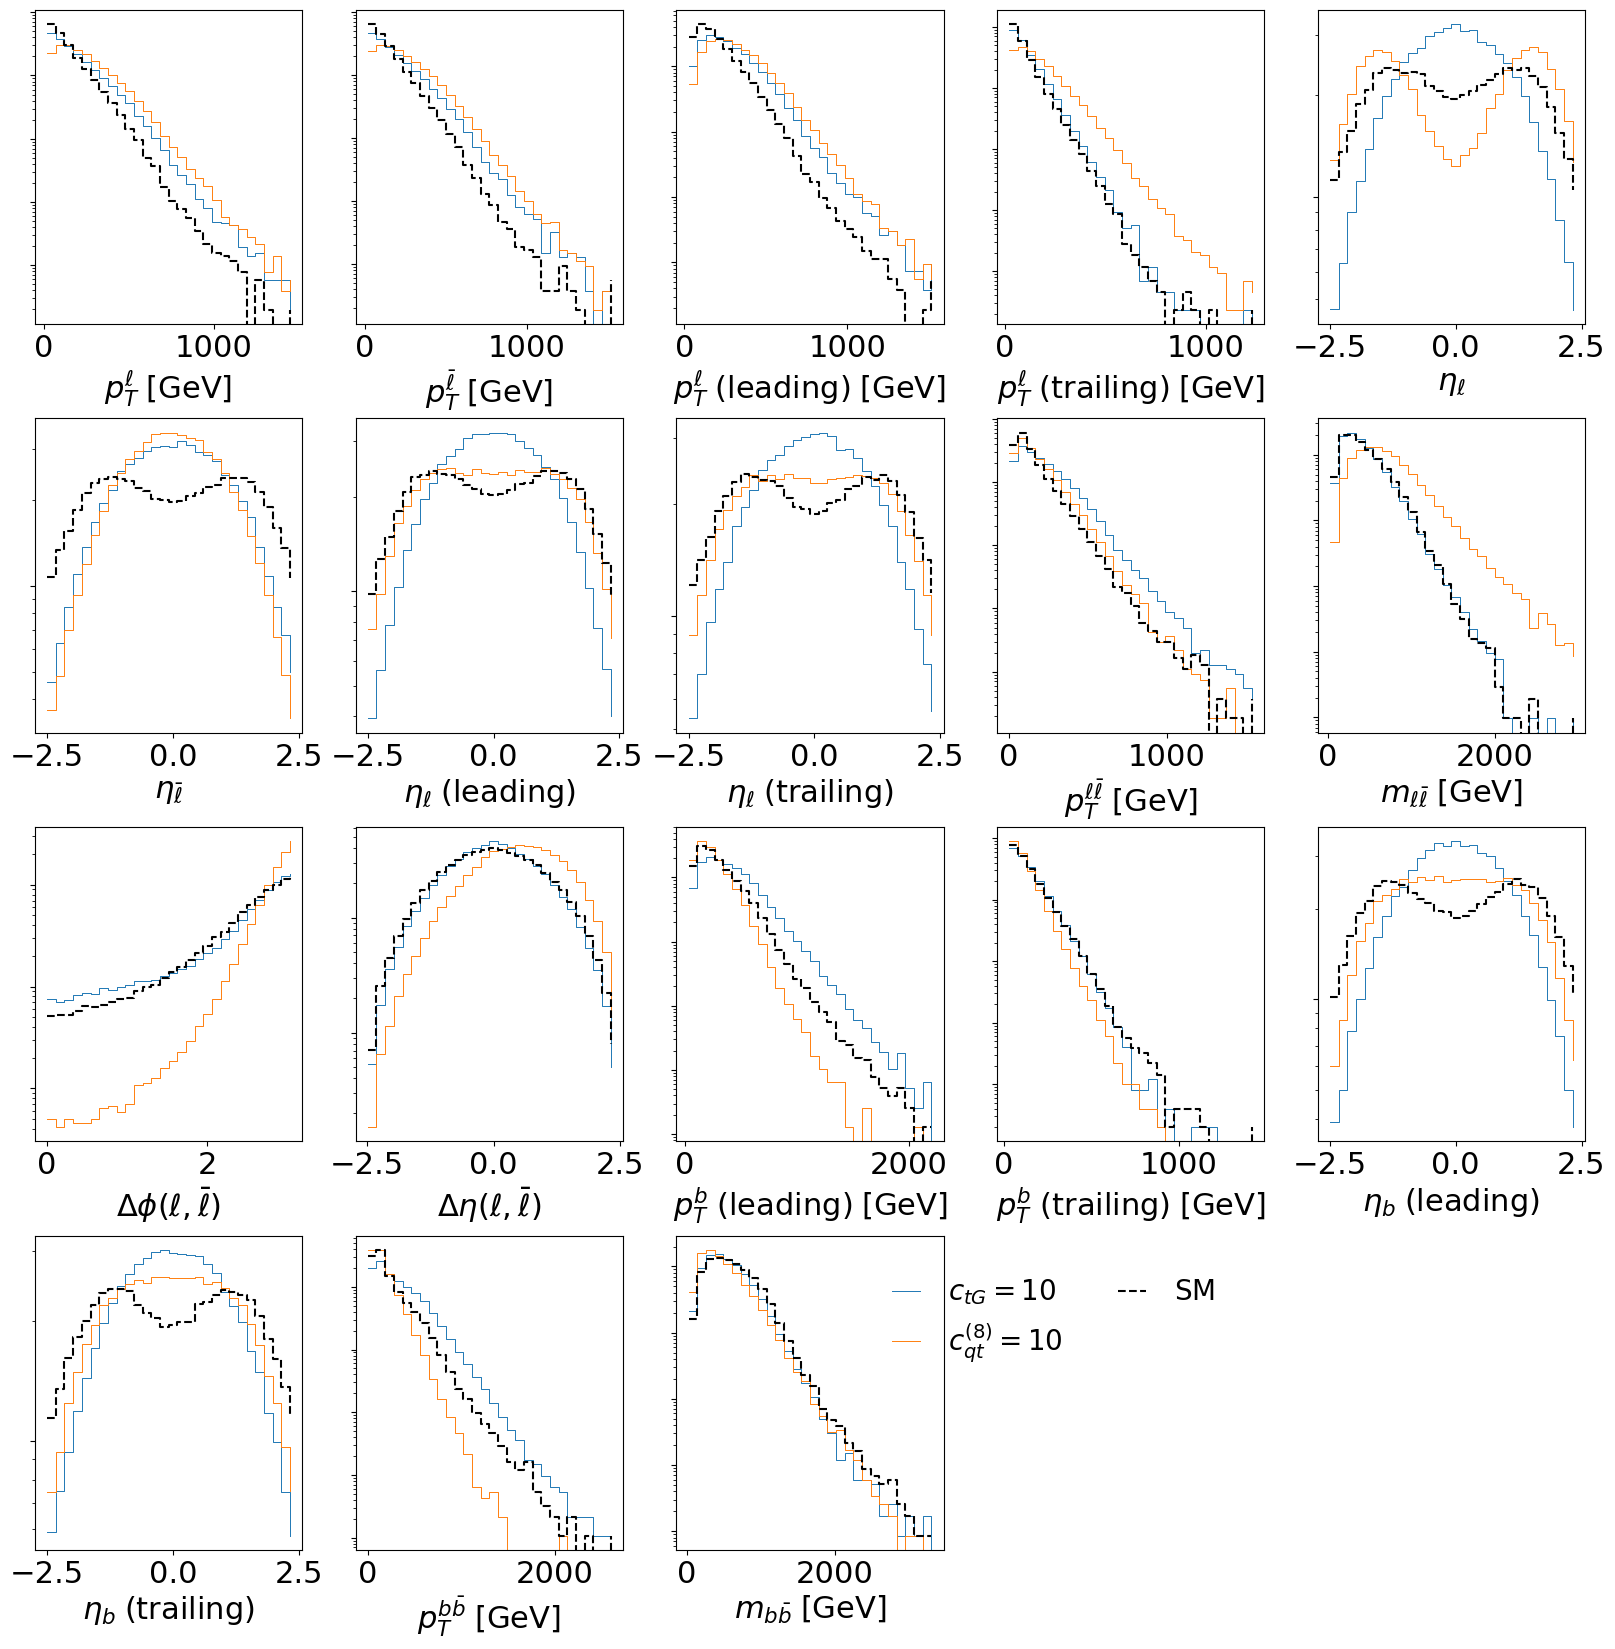

In [13]:
fig = features.plot_features(events_sm, events_eft, feature_dict, legend_labels);

In [14]:
path_to_runcard = 'https://dl.dropboxusercontent.com/s/v4ulo6icveh63fw/run_card_tt_llvlvlbb.json?dl=0'
runcard = file_downloader(path_to_runcard)

In [15]:
import json

with open(runcard) as json_runcard:
    json_runcard_loaded = json.load(json_runcard)

json_runcard_loaded

{'process_id': 'tt',
 'epochs': 2000,
 'lr': 0.0001,
 'n_batches': 50,
 'output_size': 1,
 'hidden_sizes': [100, 100, 100],
 'n_dat': 100000,
 'event_data': './downloads/training_data/',
 'features': ['pt_l1',
  'pt_l2',
  'pt_l_leading',
  'pt_l_trailing',
  'eta_l1',
  'eta_l2',
  'eta_l_leading',
  'eta_l_trailing',
  'pt_ll',
  'm_ll',
  'DeltaPhi_ll',
  'DeltaEta_ll',
  'pt_b_leading',
  'pt_b_trailing',
  'eta_b_leading',
  'eta_b_trailing',
  'pt_bb',
  'm_bb'],
 'loss_type': 'CE',
 'scaler_type': 'robust',
 'patience': 200,
 'val_ratio': 0.2,
 'c_train': {'cQd8': 10,
  'cQj18': 10,
  'cQj38': 10,
  'cQu8': 10,
  'ctd8': 10,
  'ctGRe': -10,
  'ctj8': 10,
  'ctu8': 10}}

In [16]:
json_runcard_loaded['epochs'] = 200
json_runcard_loaded['lr'] = 0.001
json_runcard_loaded['n_batches'] = 50
json_runcard_loaded['patience'] = 20 # needs to be bigger than number of epochs

In [17]:
with open(runcard, 'w') as runcard_updated:
    json.dump(json_runcard_loaded, runcard_updated)

In [ ]:
output_dir = './models'
c_name = 'ctGRe'

fitter = classifier.Fitter(json_path = runcard,
                           mc_run = 0,
                           c_name = c_name,
                           output_dir = output_dir,
                           print_log=True)

2026-02-04 14:34:11,017 [INFO] All directories created, ready to load the data
2026-02-04 14:34:11,413 [INFO] Dataset loaded from ./downloads/training_data/tt_ctGRe/events_0.pkl.gz
2026-02-04 14:34:11,464 [INFO] Dataset loaded from ./downloads/training_data/tt_sm/events_0.pkl.gz
2026-02-04 14:34:56,168 [INFO] Epoch 1, Training loss 4.262339808046818, Validation loss 6.692234173417091, Overfit counter = 0
2026-02-04 14:35:41,283 [INFO] Epoch 2, Training loss 4.053140603005886, Validation loss 4.066662885248661, Overfit counter = 0
2026-02-04 14:36:26,257 [INFO] Epoch 3, Training loss 4.036783285439014, Validation loss 4.040764823555946, Overfit counter = 0
2026-02-04 14:37:11,146 [INFO] Epoch 4, Training loss 4.030151419341564, Validation loss 4.0331151485443115, Overfit counter = 0
2026-02-04 14:37:56,054 [INFO] Epoch 5, Training loss 4.026724562048912, Validation loss 4.029470786452293, Overfit counter = 0
2026-02-04 14:38:40,666 [INFO] Epoch 6, Training loss 4.023154832422733, Valida

In [18]:
path_to_models_root = os.path.join('./models', time.strftime("%Y/%m/%d"))
order = 'lin' # or quad when quadratic models have been trained

models_paths_dict = analyse.Analyse.build_path_dict(root=path_to_models_root,
                        order=order,
                        prefix='model')

analyser = analyse.Analyse(models_paths_dict, order, all=True)

FileNotFoundError: [Errno 2] No such file or directory: './models/2026/02/07'

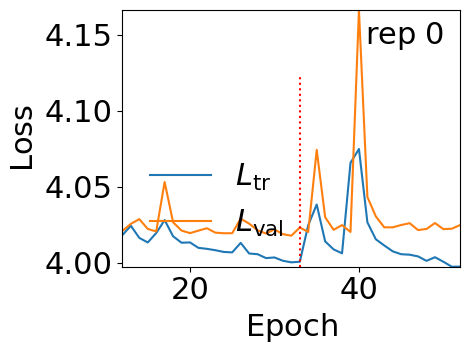

In [17]:
fig, _ = analyser.plot_loss_overview(c_name, order, xlim=12)

In [1]:
print(type(analyser))
analyser.build_model_dict()
analyser.model_df

NameError: name 'analyser' is not defined